In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Set a clean and presentation-friendly visual style
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [3]:
# Define project paths
PROJECT_ROOT = Path("../..")
DATA_RAW = PROJECT_ROOT / "data" / "raw"

excel_path = DATA_RAW / "Raisin_Dataset.xlsx"

df = pd.read_excel(excel_path)

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [4]:
csv_path = DATA_RAW / "raisin_dataset.csv"

df.to_csv(csv_path, index=False)

print(f"CSV file saved to: {csv_path}")

CSV file saved to: ..\..\data\raw\raisin_dataset.csv


In [5]:
df = pd.read_csv(csv_path)

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [6]:
df.shape

(900, 8)

In [7]:
df.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'Extent', 'Perimeter', 'Class'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    str    
dtypes: float64(5), int64(2), str(1)
memory usage: 56.4 KB


In [9]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [10]:
df.isna().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

In [11]:
df["Class"].value_counts()

Class
Kecimen    450
Besni      450
Name: count, dtype: int64

In [12]:
df["Class"].value_counts(normalize=True) * 100

Class
Kecimen    50.0
Besni      50.0
Name: proportion, dtype: float64

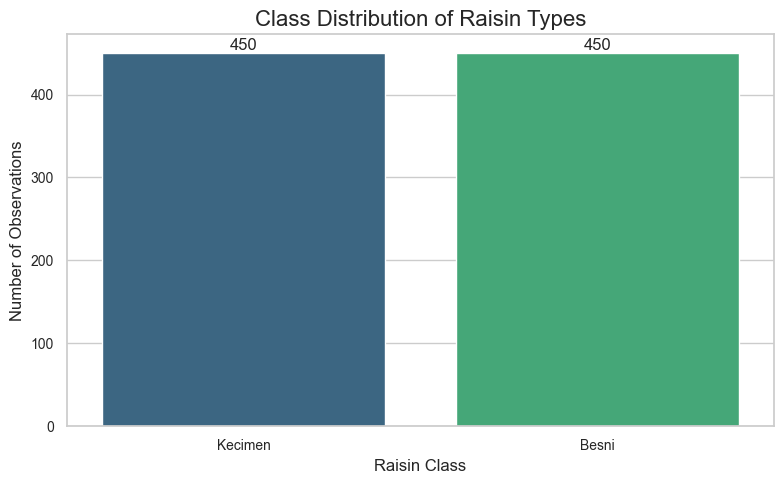

In [13]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Class",
    hue="Class",
    palette="viridis",
    legend=False
)

plt.title("Class Distribution of Raisin Types")
plt.xlabel("Raisin Class")
plt.ylabel("Number of Observations")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Target Balance

The dataset is perfectly balanced. It contains 450 observations of Kecimen raisins and 450 observations of Besni raisins.

This is a strong advantage for supervised classification because the model will learn from an equal number of examples from both classes. It also makes accuracy more meaningful compared to highly imbalanced datasets.

## Initial Dataset Summary

The Raisin dataset contains 900 observations and 8 columns. Seven columns are numerical features describing the shape and size of each raisin, and one column is the target variable: `Class`.

The target variable contains two raisin types: Kecimen and Besni. The dataset is perfectly balanced, with 450 observations for each class. There are no missing values in the dataset.

This makes the dataset suitable for supervised classification using models such as Decision Tree, Random Forest and XGBoost.

In [15]:
numeric_features = df.drop(columns="Class").columns.tolist()

numeric_features

['Area',
 'MajorAxisLength',
 'MinorAxisLength',
 'Eccentricity',
 'ConvexArea',
 'Extent',
 'Perimeter']

In [16]:
class_summary = df.groupby("Class")[numeric_features].mean().T

class_summary

Class,Besni,Kecimen
Area,112194.788889,63413.466667
MajorAxisLength,509.000652,352.859249
MinorAxisLength,279.623674,229.352592
Eccentricity,0.821125,0.741960
ConvexArea,116675.824444,65696.355556
Extent,0.691242,0.707774
Perimeter,1348.127036,983.686236


## Mean Feature Values by Class

To understand how the two raisin types differ, we first compare the average value of each numerical feature for Kecimen and Besni.

This gives us an early indication of which features may be useful for classification.

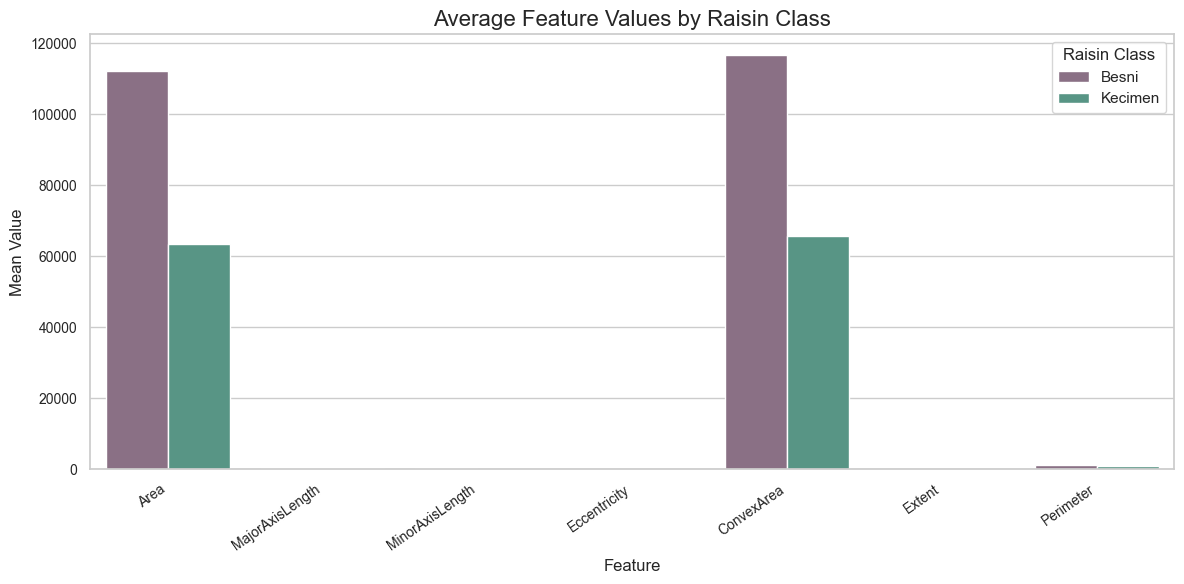

In [17]:
class_summary_plot = class_summary.reset_index().melt(
    id_vars="index",
    var_name="Class",
    value_name="Mean Value"
)

class_summary_plot = class_summary_plot.rename(columns={"index": "Feature"})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=class_summary_plot,
    x="Feature",
    y="Mean Value",
    hue="Class",
    palette=["#8E6C88", "#4E9F8A"]
)

plt.title("Average Feature Values by Raisin Class")
plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Raisin Class")

plt.tight_layout()
plt.show()

The bar chart shows that several physical measurements differ between the two raisin classes. Features such as Area, ConvexArea, Perimeter and MajorAxisLength appear to have different average values between Kecimen and Besni.

This suggests that size and shape-related features may be important for classifying the raisin type.

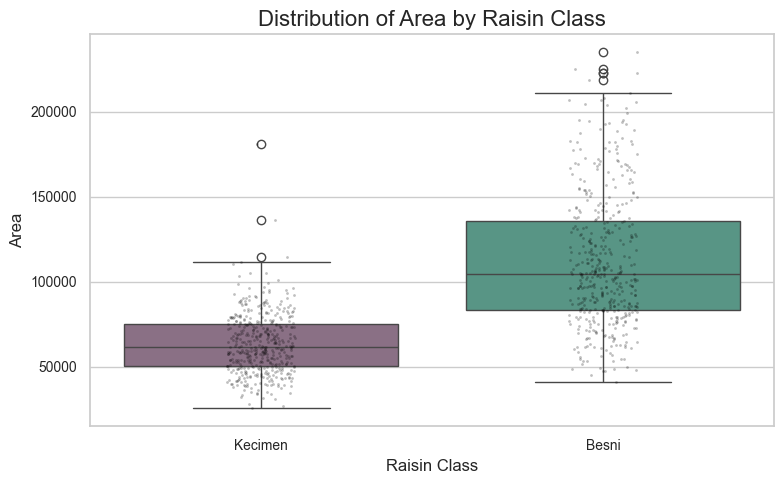

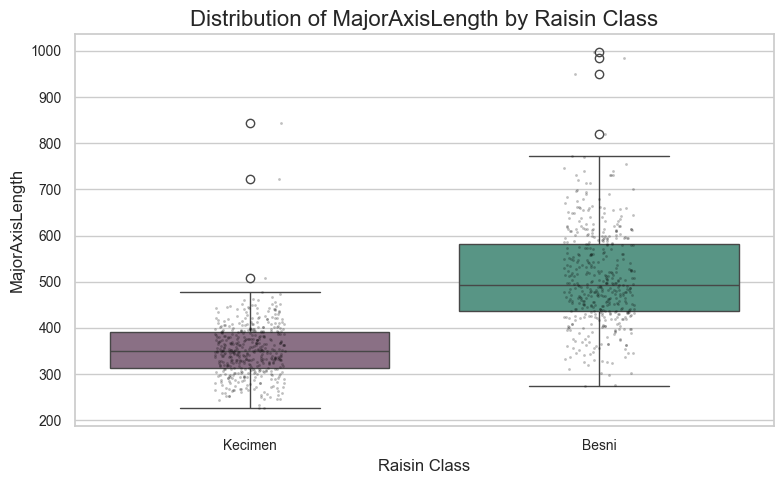

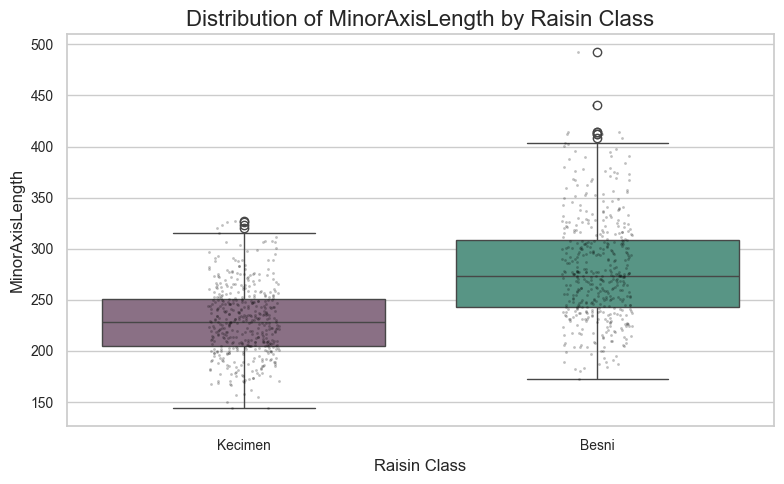

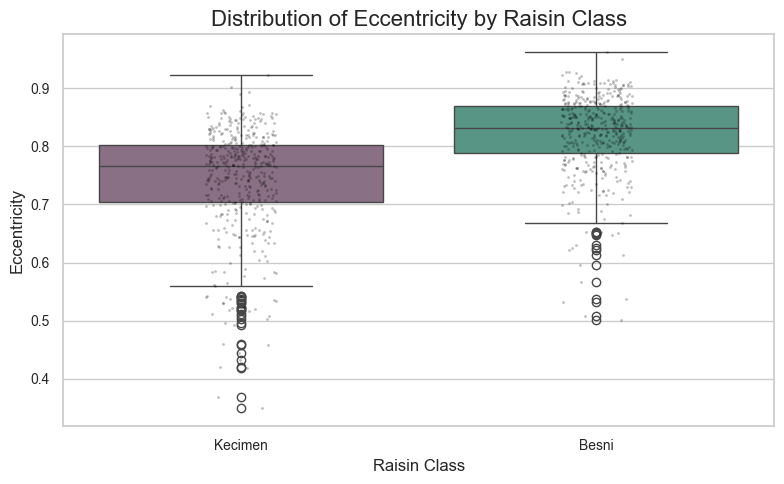

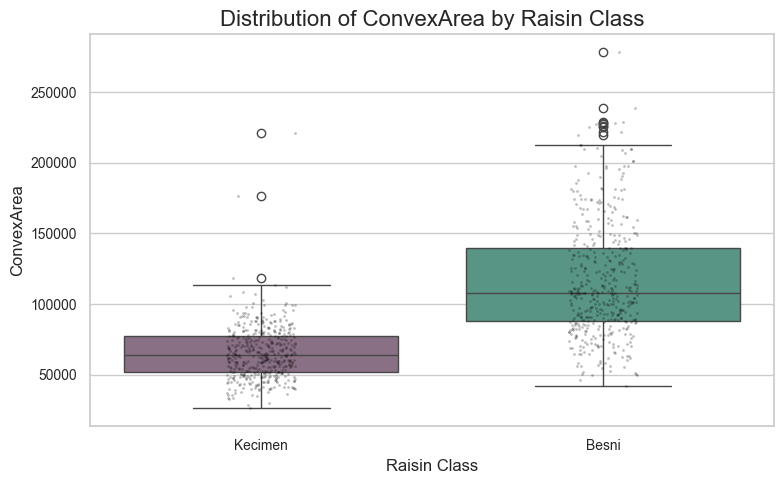

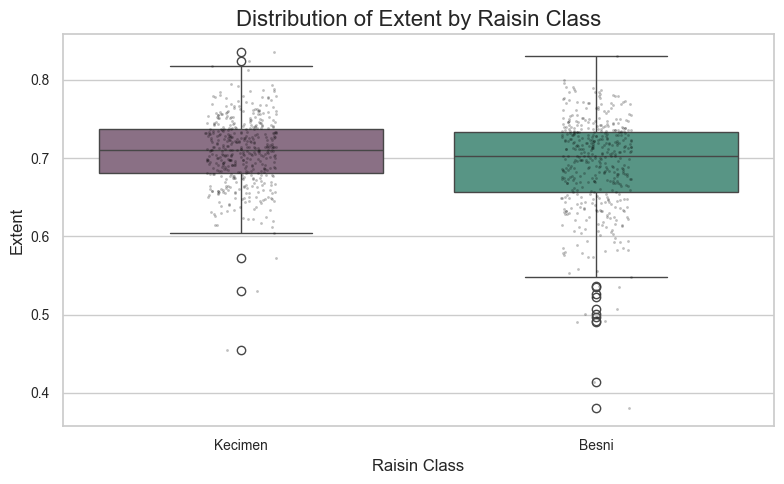

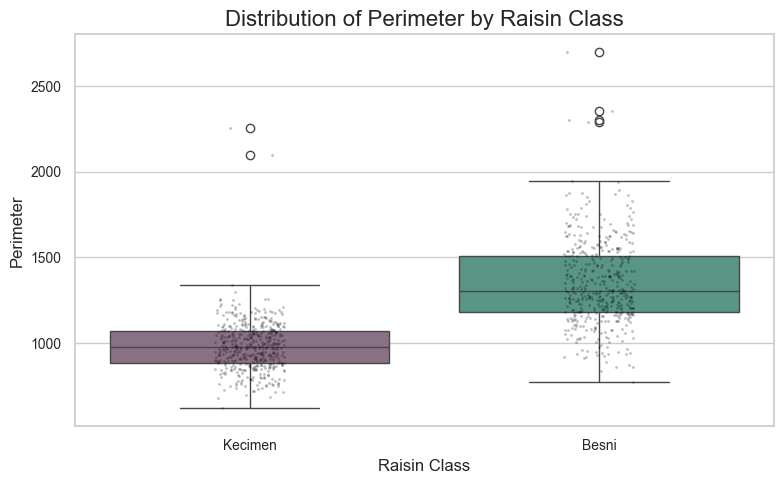

In [18]:
for feature in numeric_features:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        hue="Class",
        palette=["#8E6C88", "#4E9F8A"],
        legend=False
    )
    
    sns.stripplot(
        data=df,
        x="Class",
        y=feature,
        color="black",
        alpha=0.25,
        size=2
    )
    
    plt.title(f"Distribution of {feature} by Raisin Class")
    plt.xlabel("Raisin Class")
    plt.ylabel(feature)
    
    plt.tight_layout()
    plt.show()

## Feature Distributions by Class

Boxplots help us compare the distribution of each feature between Kecimen and Besni. They show the median, spread and possible outliers.

If the boxes for the two classes are clearly separated, the feature may be useful for classification. If they overlap a lot, the feature may be less informative on its own.

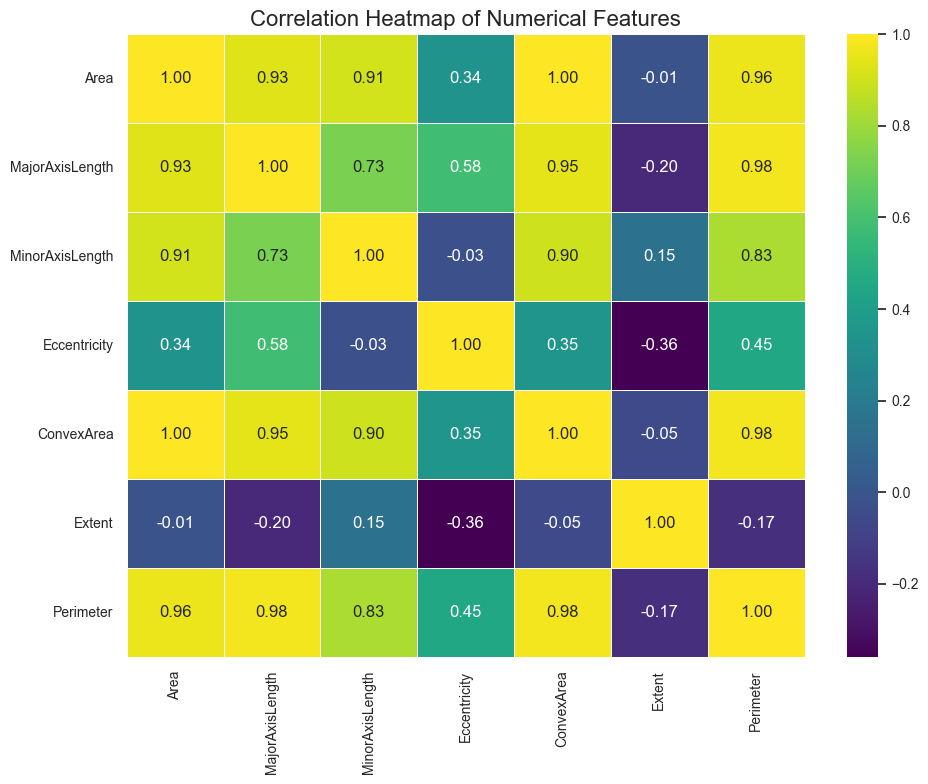

In [19]:
plt.figure(figsize=(10, 8))

corr = df[numeric_features].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

## Correlation Between Features

The correlation heatmap shows how strongly the numerical features are related to each other.

Some variables, such as Area, ConvexArea and Perimeter, are expected to be strongly correlated because they all describe the size of the raisin. This is important to understand before modeling, because some features may carry similar information.

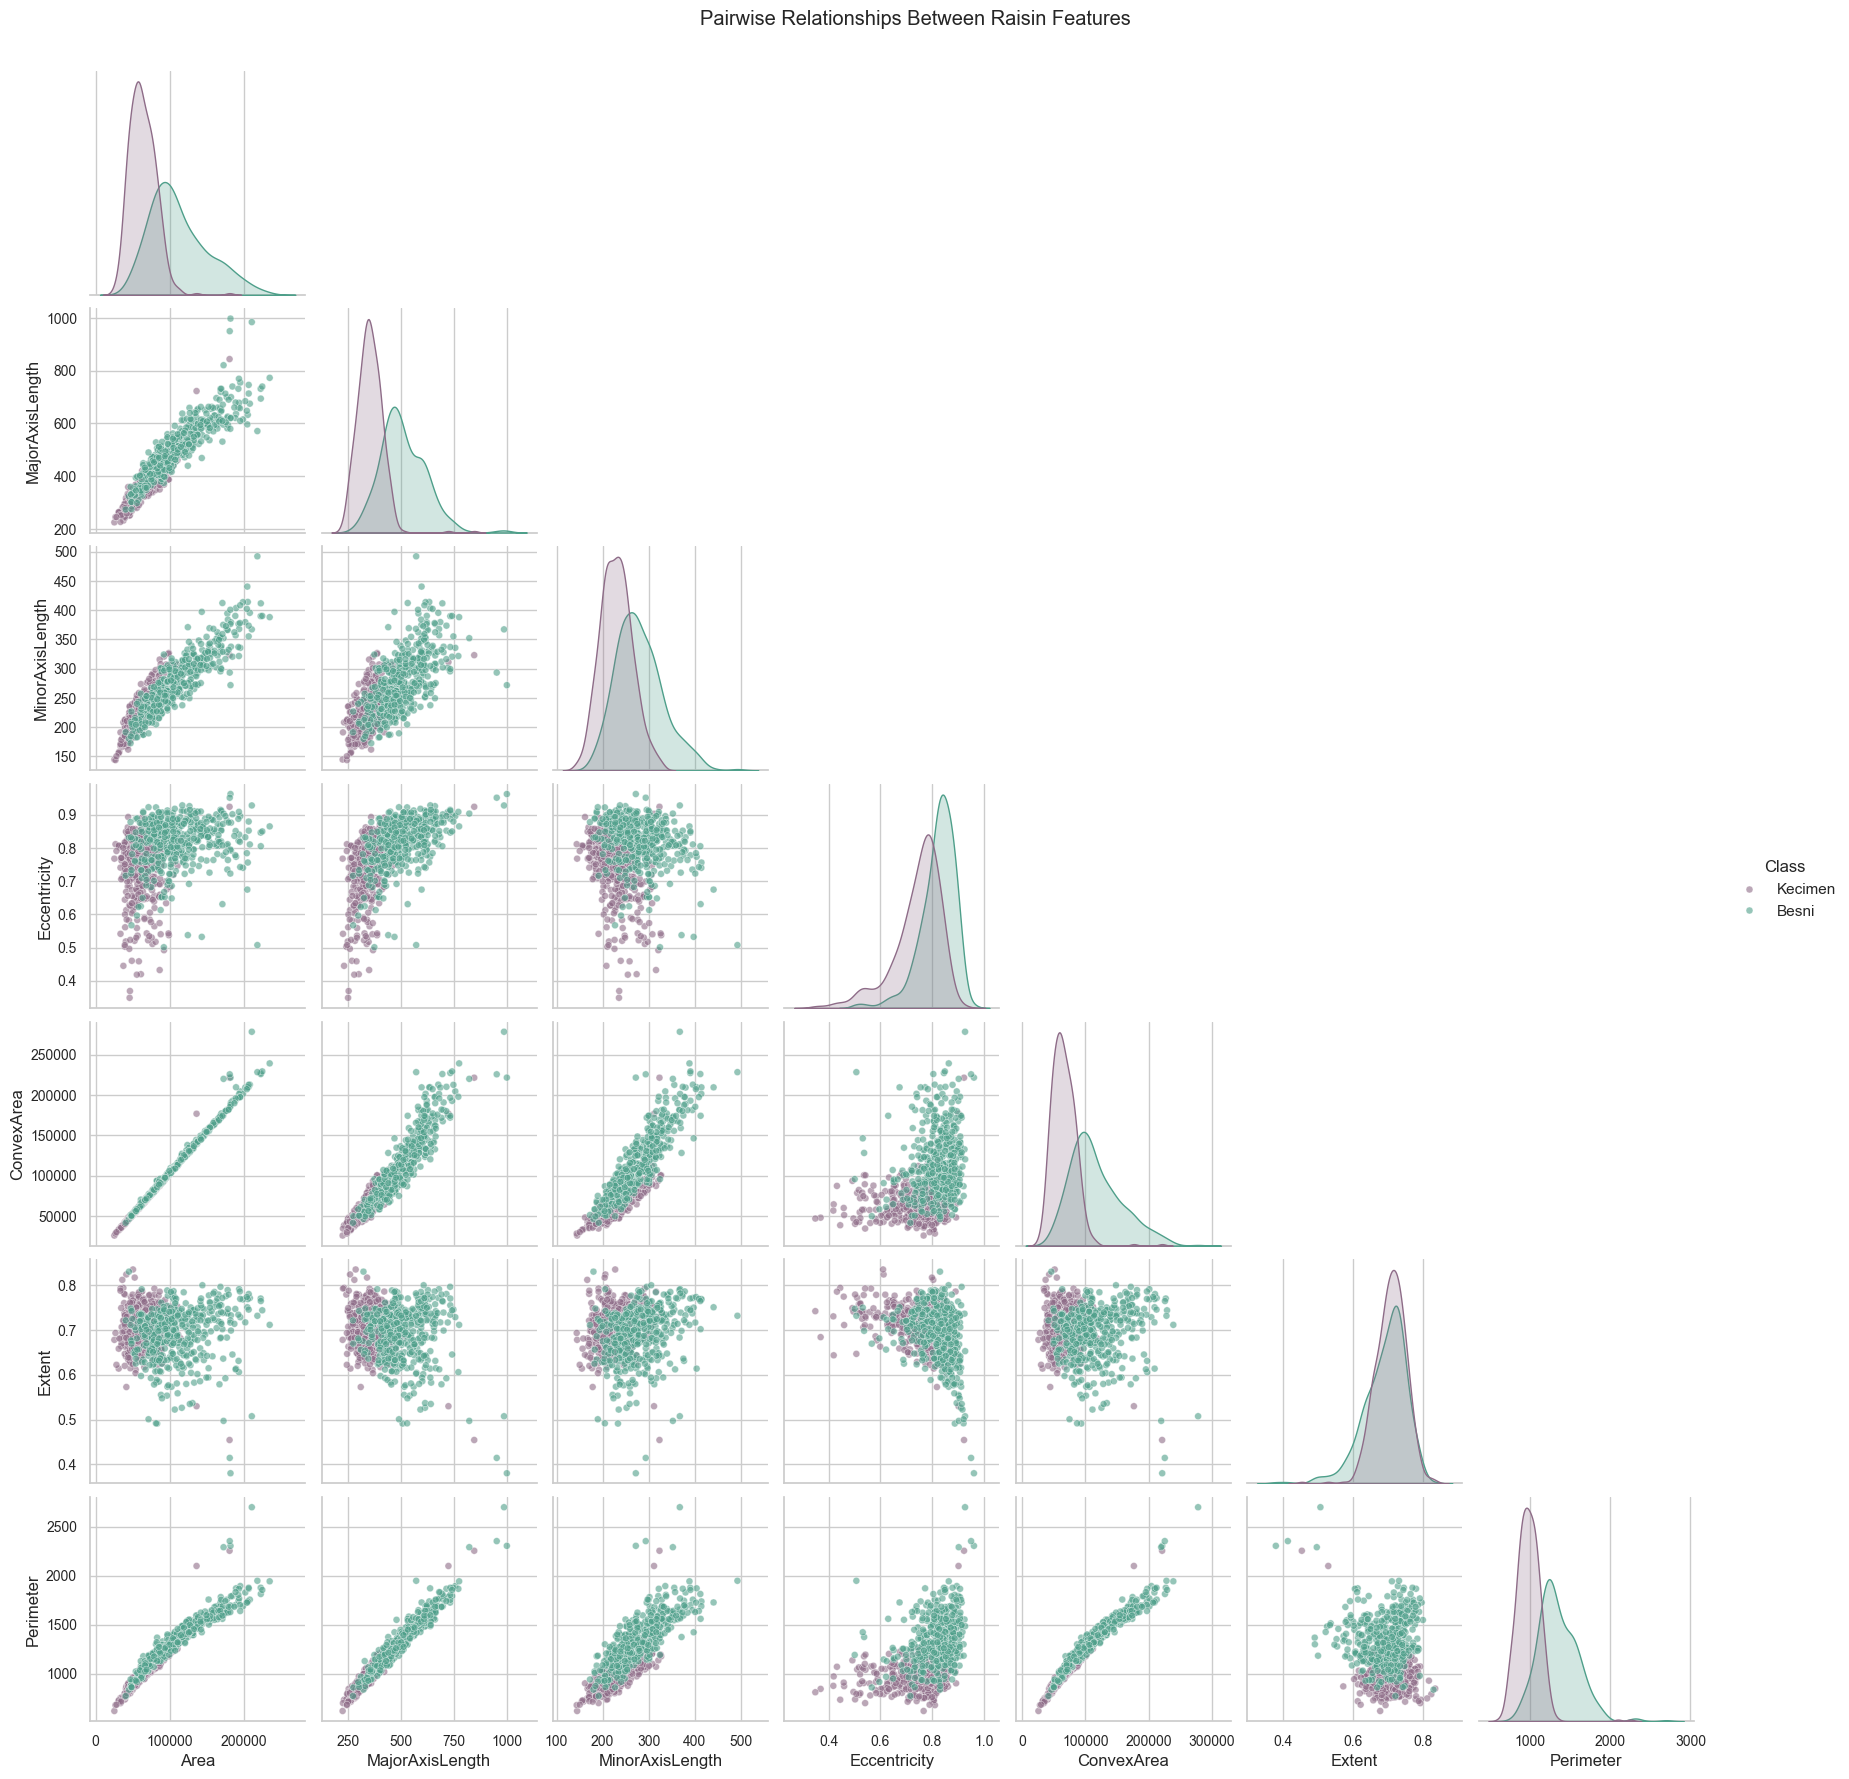

In [20]:
sns.pairplot(
    df,
    hue="Class",
    vars=numeric_features,
    palette=["#8E6C88", "#4E9F8A"],
    corner=True,
    plot_kws={"alpha": 0.6, "s": 25}
)

plt.suptitle("Pairwise Relationships Between Raisin Features", y=1.02)
plt.show()

## EDA Summary

The initial exploratory data analysis shows that the Raisin dataset is clean, balanced and suitable for supervised classification.

The dataset contains 900 observations, 7 numerical features and one target variable: `Class`. There are no missing values, and the two classes, Kecimen and Besni, are perfectly balanced with 450 observations each.

The visual analysis shows that several size-related features, such as Area, ConvexArea, Perimeter and MajorAxisLength, differ between the two raisin types. The correlation heatmap also shows that many of these variables are strongly correlated, which is expected because they describe similar physical properties of the raisins.

This gives us a strong foundation for building classification models such as Decision Tree, Random Forest and XGBoost.